## Introduction


### Dataset
The dataset used for this analysis is the "Fake News Classification" dataset from Kaggle. It contains news articles labeled as "fake" or "real". The dataset includes the following columns:
- `id`: Unique identifier for each news article
- `title`: The title of the news article
- `text`: The full text of the news article
- `label`: The label indicating whether the news is "fake" (0) or "real" (1)

### Objective
The objective of this analysis is to build a machine learning model that can classify news articles as fake or real based on their content.
We will perform the following steps:
1. Data Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Building
5. Model Evaluation
6. Conclusion

### Data Preprocessing

In [39]:
import nltk
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pandas as pd

from spellchecker import SpellChecker
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv("WELFake_Dataset.csv")

In [3]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [4]:
df.shape

(72134, 4)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [4]:
df.isnull().sum()

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

In [5]:
# remove data with text null
df = df[["title", "text", "label"]].dropna(subset=['text'])
# substitue null values with "" in title column
df['title'] = df['title'].fillna("")

In [6]:
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


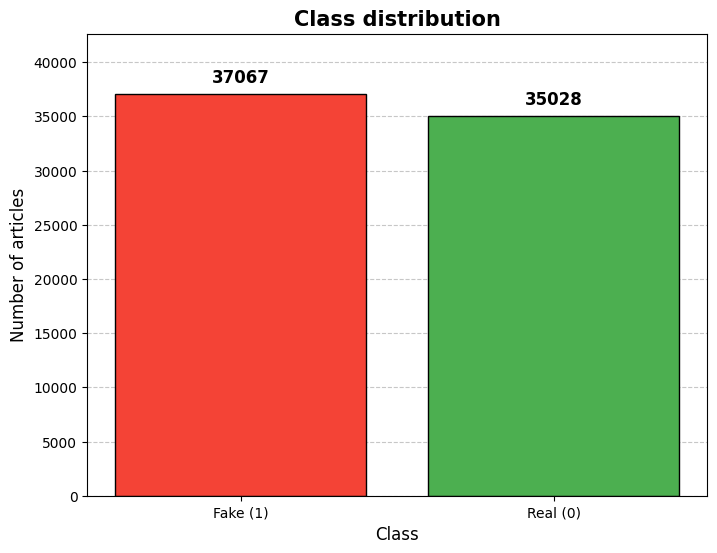

In [20]:
counts = df['label'].value_counts()
labels = ['Real (0)' if idx == 0 else 'Fake (1)' for idx in counts.index]

plt.figure(figsize=(8, 6))
colors = ['#4CAF50' if idx == 0 else '#F44336' for idx in counts.index]

bars = plt.bar(labels, counts.values, color=colors, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, # X position (center of the bar)
        height + (height * 0.02),          # Y position (slightly above the bar)
        f'{int(height)}',                  # Text to display
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

plt.title('Class distribution', fontsize=15, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of articles', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.ylim(0, max(counts.values) * 1.15) 

plt.show()

### Stylometric Feature Engineering

In [21]:
# add column with the length of the text
df['text_length'] = df['text'].apply(len)
# add column with uppercase chars ratio in the title
df['title_uppercase_ratio'] = df['title'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
# add column with ratio of exclamation point and question mark in the title
df['title_exclamation_ratio'] = df['title'].apply(lambda x: (x.count('!') + x.count('?')) / len(x) if len(x) > 0 else 0)
# add column with ratio of exclamation point and question mark in the text
df['text_exclamation_ratio'] = df['text'].apply(lambda x: (x.count('!') + x.count('?')) / len(x) if len(x) > 0 else 0)

In [30]:
df['full_text'] = df['title'] + " " + df['text']

### Linguistic Integrity and Noise Removal
First we will define a function to calculate spelling errors ratio, which is a stylometric feature that can help in distinguishing between fake and real news articles. The function will use the `pyspellchecker` library to identify misspelled words in the text and calculate the ratio of spelling errors to total words.

After that, we will apply this function to the dataset to create a new feature called `spelling_errors_ratio`. This feature will be added to our stylometric features for further analysis and modeling.

Finally, we will clean the text data by removing HTML tags, URLs, and non-alphanumeric characters. This will help in reducing noise and improving the quality of the textual features for our model.

In [34]:
spell = SpellChecker()

def count_spelling_errors(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0
    # Divide into words
    words = re.findall(r'\b\w+\b', text.lower())
    if len(words) == 0:
        return 0
    
    misspelled = spell.unknown(words)
    return len(misspelled) / len(words)


print("Calculating...")
df['spelling_errors_ratio'] = df['full_text'].apply(count_spelling_errors)

Calculating...


In [43]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Noise Removal (HTML, URLs, non-alphanumeric)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    # 2. Case Folding
    text = text.lower()
    
    # 4. Tokenization 
    tokens = word_tokenize(text)
    
    # 3. Stopword Elimination
    filtered_tokens = [w for w in tokens if w not in stop_words]
    
    return " ".join(filtered_tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Advancia\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Advancia\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Advancia\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [36]:
df["cleaned_text"] = df["full_text"].apply(clean_text)

### Vectorization and Scaling
Here the idea is to create two separate pipelines: one for the textual features (TF-IDF) and one for the stylometric features (StandardScaler). Then we will combine them into a single feature set for modeling.

Steps:
1. Define Xs and y, one X is the textual features (the cleaned text) and the other X is the stylometric features (the engineered features).
2. Split the dataset into training and test sets (80% training, 20% test).
3. Apply TF-IDF vectorization to the textual features (fit on train, transform on test).
4. Apply StandardScaler to the stylometric features (fit on train, transform on test).
5. Combine the TF-IDF features and the scaled stylometric features into a single feature set for both training and test data.

This process is useful to avoid DATA LEAKAGE, ensuring that the transformations are only learned from the training data and then applied to the test data.

In [ ]:
# 1. Define features (X) and target (y)
X_stylometric = df[['text_length', 'title_uppercase_ratio', 
                    'title_exclamation_ratio', 'text_exclamation_ratio', 
                    'spelling_errors_ratio']]
X_text = df['cleaned_text']
y = df['label']

# 2. SPLIT DEL DATASET (L'80% training set, 20% test set)
X_text_train, X_text_test, X_stylo_train, X_stylo_test, y_train, y_test = train_test_split(
    X_text, X_stylometric, y, test_size=0.2, random_state=42, stratify=y
)

# 3. TF-IDF
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test = tfidf.transform(X_text_test)

# 4. SCALER 
scaler = StandardScaler()
X_stylo_scaled_train = scaler.fit_transform(X_stylo_train)
X_stylo_scaled_test = scaler.transform(X_stylo_test) # Solo transform!

# 5. COMBINE FINAL MATRICES
X_train_final = hstack([X_tfidf_train, X_stylo_scaled_train])
X_test_final = hstack([X_tfidf_test, X_stylo_scaled_test])

## DATA MODELING